In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD

import torch
import numpy as np



In [3]:
import projections.dct_projections as dct_projections
import projections.random_projections as random_projections
import projections.range_finder_projections as range_finder_projections
import projections.randomized_svd_projections as randomized_svd_projections
import projections.svd_projections as svd_projections

import projections.hybrid_projections as hybrid_projections

In [4]:
n_components = 20  # Number of SVD components

# Number of DCT coefficients to keep (rows, columns)
dct_rows_to_keep = 20
dct_cols_to_keep = 20
keep_dims = (dct_rows_to_keep, dct_cols_to_keep)  


In [5]:
!ls pretrained_weights_roberta_base/

input_matrix_base_model.model.roberta.encoder.layer.0.attention.output.dense.npy
input_matrix_base_model.model.roberta.encoder.layer.0.attention.self.query.npy
input_matrix_base_model.model.roberta.encoder.layer.0.attention.self.value.npy
input_matrix_base_model.model.roberta.encoder.layer.0.output.dense.npy
input_matrix_base_model.model.roberta.encoder.layer.10.attention.output.dense.npy
input_matrix_base_model.model.roberta.encoder.layer.10.attention.self.query.npy
input_matrix_base_model.model.roberta.encoder.layer.10.attention.self.value.npy
input_matrix_base_model.model.roberta.encoder.layer.10.output.dense.npy
input_matrix_base_model.model.roberta.encoder.layer.11.attention.output.dense.npy
input_matrix_base_model.model.roberta.encoder.layer.11.attention.self.query.npy
input_matrix_base_model.model.roberta.encoder.layer.11.attention.self.value.npy
input_matrix_base_model.model.roberta.encoder.layer.11.output.dense.npy
input_matrix_base_model.model.roberta.encoder.layer.1.attentio

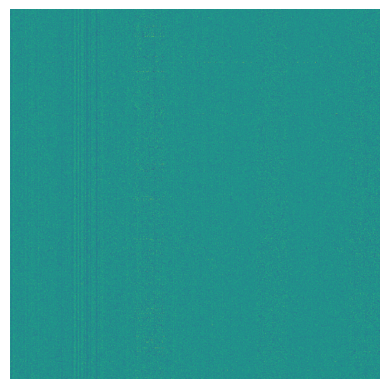

In [6]:
# Load the .npy file
# W_matrix_np = np.load('pretrained_weights_roberta_base/input_matrix_base_model.model.roberta.encoder.layer.11.attention.self.value.npy')
# W_matrix_np = np.load('pretrained_weights_roberta_base/input_matrix_base_model.model.roberta.encoder.layer.1.attention.output.dense.npy')
W_matrix_np = np.load('pretrained_weights_roberta_base/input_matrix_base_model.model.roberta.encoder.layer.3.attention.self.query.npy')

W_matrix = torch.tensor(W_matrix_np)

# Display the image
plt.imshow(W_matrix_np, cmap='viridis')  # Use cmap='gray' for single-channel images
plt.axis('off')  # Optional: remove axes
plt.show()

## Unsorted

In [7]:

# 3. Compress the matrix
print(f"Original matrix size: {W_matrix.shape}")
print(f"Keeping top {keep_dims} DCT coefficients...")

A, DCT_truncated_coeffs, B = dct_projections.compress(W_matrix, keep_dims=keep_dims, absorb_R=False)
W_DCT_reconstructed = dct_projections.reconstruct(A, DCT_truncated_coeffs, B)


Original matrix size: torch.Size([768, 768])
Keeping top (20, 20) DCT coefficients...
[dct] DCT coefficient selection method: energy
[dct] Selected row indices (DCT space): tensor([  0, 247, 300, 370, 655, 409, 566, 321, 653, 562,  11, 329, 473, 181,
        697, 539, 574,  46, 657, 165])
[dct] Selected column indices (DCT space): tensor([226, 227, 184, 303, 194, 205,  85, 183, 551, 207, 150, 344, 185, 217,
        566, 200,  60, 222, 542, 677])
[dct] A shape: torch.Size([768, 20]), R shape: torch.Size([20, 20]), B shape: torch.Size([20, 768])


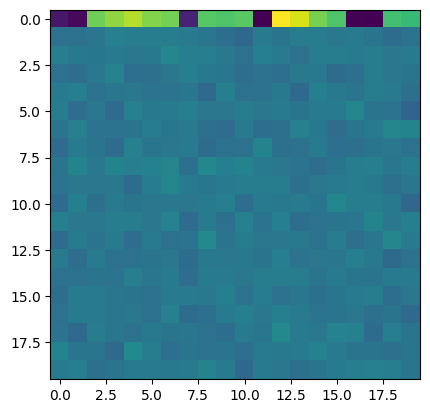

In [8]:
plt.imshow(DCT_truncated_coeffs[:keep_dims[0],:keep_dims[1]])  # Use cmap='gray' for single-channel images

In [9]:
# svd = TruncatedSVD(n_components=n_components, n_iter=10,
#                     random_state=20)
# svd.fit(W_matrix_np)
# SVD_reduced_matrix = svd.transform(W_matrix_np)

# W_SVD_reconstructed = svd.inverse_transform(SVD_reduced_matrix)


In [10]:
# A, SVD_reduced_matrix, B = svd_projections.compress(W_matrix, n_components, n_iter=10, random_state=20)
# W_SVD_reconstructed = svd_projections.reconstruct(A, SVD_reduced_matrix, B)

In [11]:
A, SVD_reduced_matrix, B = hybrid_projections.compress(W_matrix, n_components, specification="dct-1/3_svd")
W_SVD_reconstructed = hybrid_projections.reconstruct(A, SVD_reduced_matrix, B)

[hybrid] Calculating component ranks: specification dct-1/3_svd, total_rank 20
[hybrid] Component Ranks: {'dct': 6, 'svd': 14}
[hybrid] Configuration per part: {}
[dct] DCT coefficient selection method: energy
[dct] Selected row indices (DCT space): tensor([  0,   1, 643, 572, 107, 115])
[dct] Selected column indices (DCT space): tensor([113, 408, 409, 115, 254, 412])
[dct] A shape: torch.Size([768, 6]), R shape: torch.Size([6, 6]), B shape: torch.Size([6, 768])
[dct] After absorbing R, new A shape: torch.Size([768, 6]), R shape: torch.Size([6, 6])
[svd_projections.get_linear_rec_svd] input_matrix=(768, 768), rank=14, n_iter=10, random_state=42


In [12]:
# A, RP_truncated_coeffs, B = random_projections.compress(W_matrix, n_components, absorb_R=True)
# W_RP_reconstructed = random_projections.reconstruct(A, RP_truncated_coeffs, B)


A, RP_truncated_coeffs, B = range_finder_projections.compress(W_matrix, n_components, n_power_iter=5, absorb_R=True)
W_RP_reconstructed = range_finder_projections.reconstruct(A, RP_truncated_coeffs, B)

[randomized_range_finder] Config: oversampling=5, n_power_iter=0


In [13]:

# A, RP_truncated_coeffs, B = randomized_svd_projections2.compress(W_matrix, n_components, 5, absorb_R=True)
# W_RP_reconstructed = randomized_svd_projections2.reconstruct(A, RP_truncated_coeffs, B)

In [14]:
A.shape, B.shape

(torch.Size([768, 20]), torch.Size([20, 768]))

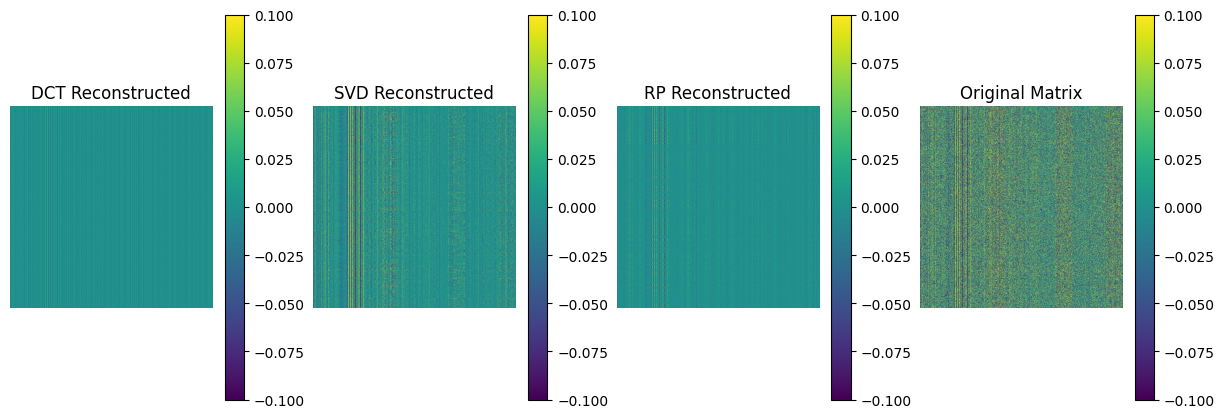

In [15]:

f, axs = plt.subplots(1, 4, figsize=(15, 5))

plt.sca(ax=axs[3])

# Display the image
# plt.imshow(data, cmap='viridis')  # Use cmap='gray' for single-channel images
plt.imshow(W_matrix_np, cmap='viridis', vmin=-0.1, vmax=0.1)  # Use cmap='gray' for single-channel images

plt.title('Original Matrix')
plt.axis('off')  # Optional: remove axes
cb = plt.colorbar()
# plt.show()

plt.sca(ax=axs[0])
# Display the image
plt.imshow(W_DCT_reconstructed, cmap='viridis', vmin=cb.vmin, vmax=cb.vmax)  # Use cmap='gray' for single-channel images
plt.title('DCT Reconstructed')
plt.axis('off')  # Optional: remove axes
cb = plt.colorbar()

# plt.show()


plt.sca(ax=axs[1])
# Display the image
plt.imshow(W_SVD_reconstructed, cmap='viridis', vmin=cb.vmin, vmax=cb.vmax)  # Use cmap='gray' for single-channel images
plt.title('SVD Reconstructed')
plt.axis('off')  # Optional: remove axes
cb = plt.colorbar()

# plt.show()


plt.sca(ax=axs[2])
# Display the image
plt.imshow(W_RP_reconstructed, cmap='viridis', vmin=cb.vmin, vmax=cb.vmax)  # Use cmap='gray' for single-channel images
plt.title('RP Reconstructed')
plt.axis('off')  # Optional: remove axes
cb = plt.colorbar()

# plt.show()


## Sorted

In [17]:
# Get sorting indices (permutation for each row)
col_perm_indices = np.argsort(W_matrix_np, axis=1)


# # # The same sorting for each row based on total column sums
col_sums = np.sum(W_matrix_np, axis=0)
total_col_perm_indices = np.argsort(col_sums)
total_col_perm_indices = np.tile(total_col_perm_indices, (W_matrix_np.shape[0], 1))

col_perm_indices = total_col_perm_indices  # override with total column sums sorting

In [18]:

# Apply permutation to obtain sorted data (cols)
data_sorted = np.take_along_axis(W_matrix_np, col_perm_indices, axis=1)  

In [19]:
# Get sorting indices (permutation for each column)
row_perm_indices = np.argsort(data_sorted, axis=0)


# The same sorting for each column based on total row sums
row_sums = np.sum(data_sorted, axis=1)
total_row_perm_indices = np.argsort(row_sums)
total_row_perm_indices = np.tile(total_row_perm_indices, (W_matrix_np.shape[1], 1)).T

row_perm_indices = total_row_perm_indices  # override with total row sums sorting

In [20]:
# Apply permutation to obtain sorted data (rows)

data_sorted = np.take_along_axis(data_sorted, row_perm_indices, axis=0)

In [21]:
col_perm_indices

array([[153, 139, 144, ..., 176, 134, 142],
       [153, 139, 144, ..., 176, 134, 142],
       [153, 139, 144, ..., 176, 134, 142],
       ...,
       [153, 139, 144, ..., 176, 134, 142],
       [153, 139, 144, ..., 176, 134, 142],
       [153, 139, 144, ..., 176, 134, 142]])

In [22]:
row_perm_indices

array([[679, 679, 679, ..., 679, 679, 679],
       [350, 350, 350, ..., 350, 350, 350],
       [ 53,  53,  53, ...,  53,  53,  53],
       ...,
       [141, 141, 141, ..., 141, 141, 141],
       [697, 697, 697, ..., 697, 697, 697],
       [749, 749, 749, ..., 749, 749, 749]])

In [23]:
# 3. Compress the matrix
print(f"Original matrix size: {W_matrix.shape}")
print(f"Keeping top {keep_dims} DCT coefficients...")

A, DCT_truncated_coeffs, B = dct_projections.compress(torch.tensor(data_sorted), keep_dims=(dct_rows_to_keep, dct_cols_to_keep), absorb_R=False)

W_DCT_reconstructed = dct_projections.reconstruct(A, DCT_truncated_coeffs, B)

Original matrix size: torch.Size([768, 768])
Keeping top (20, 20) DCT coefficients...
[dct] DCT coefficient selection method: energy
[dct] Selected row indices (DCT space): tensor([  0,   1,   3, 629, 122, 253, 465, 200, 156,   9, 383,  38, 108, 440,
        446,  97, 571, 120, 709, 175])
[dct] Selected column indices (DCT space): tensor([  1,   3,   5,   7,   9,  11,  13,  15, 190, 359, 312,  22, 750,  17,
        543, 763, 115, 330, 735, 583])
[dct] A shape: torch.Size([768, 20]), R shape: torch.Size([20, 20]), B shape: torch.Size([20, 768])


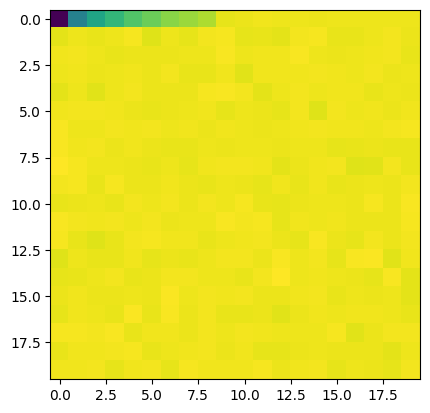

In [24]:
plt.imshow(DCT_truncated_coeffs)  # Use cmap='gray' for single-channel images

In [25]:
svd = TruncatedSVD(n_components=n_components, n_iter=10,
                    random_state=20)
svd.fit(data_sorted)
SVD_reduced_matrix = svd.transform(data_sorted)

W_SVD_reconstructed = svd.inverse_transform(SVD_reduced_matrix)


(-0.5, 767.5, 767.5, -0.5)

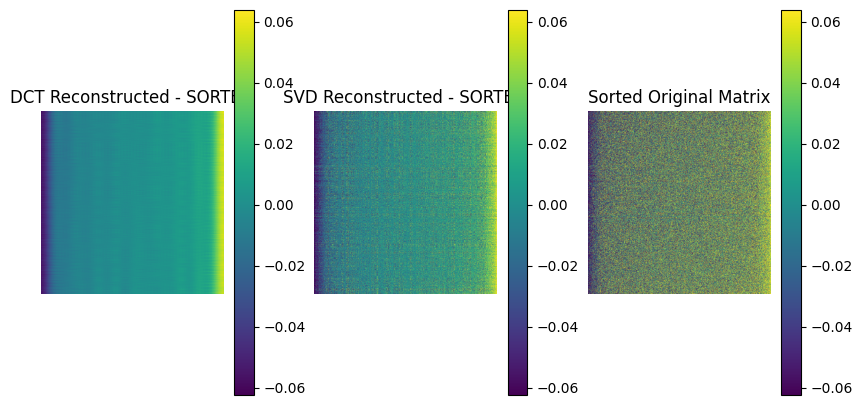

In [26]:

f, axs = plt.subplots(1, 3, figsize=(10, 5))

plt.sca(ax=axs[0])
# Display the image
plt.imshow(W_DCT_reconstructed, cmap='viridis')  # Use cmap='gray' for single-channel images
plt.title('DCT Reconstructed - SORTED')
cb = plt.colorbar()
plt.axis('off')  # Optional: remove axes
# plt.show()


plt.sca(ax=axs[1])
# Display the image
plt.imshow(W_SVD_reconstructed, cmap='viridis', vmin=cb.vmin, vmax=cb.vmax)  # Use cmap='gray' for single-channel images
plt.title('SVD Reconstructed - SORTED')
plt.colorbar()
plt.axis('off')  # Optional: remove axes
# plt.show()

plt.sca(ax=axs[2])

# Display the image
plt.imshow(data_sorted, cmap='viridis', vmin=cb.vmin, vmax=cb.vmax)  # Use cmap='gray' for single-channel images
plt.title('Sorted Original Matrix') 
plt.colorbar()
plt.axis('off')  # Optional: remove axes
# plt.show()

In [27]:
# --- Restore the original data ---
# Inverse permutation = argsort of perm_indices
col_inv_perm_indices = np.argsort(col_perm_indices, axis=1)
row_inv_perm_indices = np.argsort(row_perm_indices, axis=0)

data_restored = np.take_along_axis(data_sorted, row_inv_perm_indices, axis=0)
W_SVD_reconstructed_unsorted = np.take_along_axis(W_SVD_reconstructed, row_inv_perm_indices, axis=0)
W_DCT_reconstructed_unsorted = np.take_along_axis(W_DCT_reconstructed, row_inv_perm_indices, axis=0)


data_restored = np.take_along_axis(data_restored, col_inv_perm_indices, axis=1)
W_SVD_reconstructed_unsorted = np.take_along_axis(W_SVD_reconstructed_unsorted, col_inv_perm_indices, axis=1)
W_DCT_reconstructed_unsorted = np.take_along_axis(W_DCT_reconstructed_unsorted, col_inv_perm_indices, axis=1)

# Verify correctness
assert np.allclose(W_matrix_np, data_restored)

In [28]:
# Uncompress and reorder automatically
A, R, B = dct_projections.permute_and_compress(torch.tensor(W_matrix_np), 
                                               permutations="global",
                                               keep_dims=(dct_rows_to_keep, dct_cols_to_keep), absorb_R=True)
W_DCT_reconstructed_unsorted_auto = dct_projections.reconstruct(A, R, B)

[dct] DCT coefficient selection method: energy
[dct] Selected row indices (DCT space): tensor([  0,   1, 643, 572, 107, 115, 681, 556, 178, 117, 492, 589,  77, 402,
        228, 417, 754, 593, 362, 479])
[dct] Selected column indices (DCT space): tensor([113, 408, 409, 115, 254, 412, 275, 410,  67, 141, 109, 152, 402, 724,
        279,  87, 217, 399, 316,  88])
[dct] A shape: torch.Size([768, 20]), R shape: torch.Size([20, 20]), B shape: torch.Size([20, 768])
[dct] After absorbing R, new A shape: torch.Size([768, 20]), R shape: torch.Size([20, 20])


(-0.5, 767.5, 767.5, -0.5)

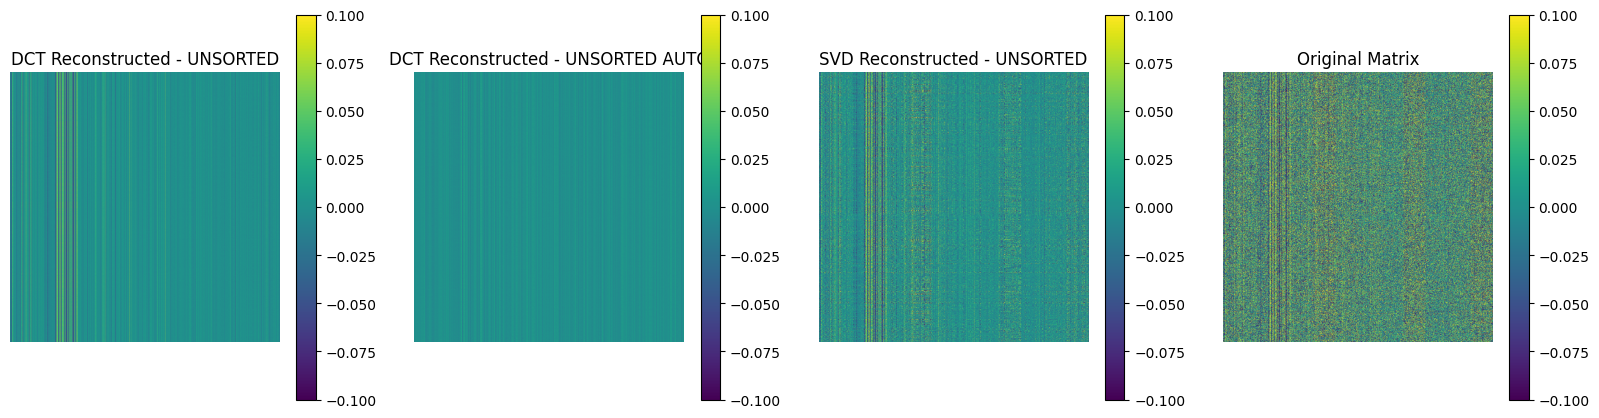

In [29]:
f, axs = plt.subplots(1, 4, figsize=(20, 5))

plt.sca(ax=axs[3])

# Display the image
plt.imshow(W_matrix_np, cmap='viridis', vmin=-0.1, vmax=0.1)  # Use cmap='gray' for single-channel images
plt.title('Original Matrix')
cb = plt.colorbar()
plt.axis('off')  # Optional: remove axes
# plt.show()

plt.sca(ax=axs[0])
# Display the image
plt.imshow(W_DCT_reconstructed_unsorted, cmap='viridis', vmin=cb.vmin, vmax=cb.vmax)  # Use cmap='gray' for single-channel images
plt.title('DCT Reconstructed - UNSORTED')
plt.axis('off')  # Optional: remove axes
plt.colorbar()
# plt.show()

plt.sca(ax=axs[1])
# Display the image
plt.imshow(W_DCT_reconstructed_unsorted_auto, cmap='viridis', vmin=cb.vmin, vmax=cb.vmax)  # Use cmap='gray' for single-channel images
plt.title('DCT Reconstructed - UNSORTED AUTO')
plt.axis('off')  # Optional: remove axes
plt.colorbar()
# plt.show()



plt.sca(ax=axs[2])
# Display the image
plt.imshow(W_SVD_reconstructed_unsorted, cmap='viridis', vmin=cb.vmin, vmax=cb.vmax)  # Use cmap='gray' for single-channel images
plt.title('SVD Reconstructed - UNSORTED')
plt.colorbar()
plt.axis('off')  # Optional: remove axes
# plt.show()

In [30]:
# Compute maximum relative error percentage between the two DCT reconstructions
max_relative_err_percent = (abs(W_DCT_reconstructed_unsorted_auto-W_DCT_reconstructed_unsorted)/abs(W_DCT_reconstructed_unsorted)*100).max()

max_relative_err_percent

tensor(5.5219e+08)

In [31]:
from typing import Tuple


def run_svd(
    input_matrix: np.ndarray, rank: int, n_iter: int, random_state: int
) -> Tuple[np.ndarray, TruncatedSVD]:
    svd = TruncatedSVD(n_components=rank, n_iter=n_iter,
                       random_state=random_state)
    svd.fit(input_matrix)
    reduced_matrix = svd.transform(input_matrix)
    return reduced_matrix, svd


def get_linear_rec_svd(
    input_matrix: np.ndarray, rank: int, n_iter: int, random_state: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    print(f"[get_linear_rec_svd] input_matrix={input_matrix.shape}, rank={rank}, n_iter={n_iter}, random_state={random_state}")
    reduced_matrix, svd = run_svd(input_matrix, rank, n_iter, random_state)

    reconstructed_matrix = svd.inverse_transform(reduced_matrix)
    return reconstructed_matrix, reduced_matrix, svd.components_


def get_replacement_module(weight, module_name, reconstruction_type, writer, reconstruct_config):
    cfg = reconstruct_config[reconstruction_type]
    if reconstruction_type == "svd":

        # Save input_matrix to a file for inspection/debugging
        np.save(f"input_matrix_{module_name}.npy",  weight.cpu().detach().numpy(),)

        reconstructed_matrix, enc, dec = get_linear_rec_svd(
            weight.cpu().detach().numpy(),
            cfg["rank"],
            cfg["n_iter"],
            cfg["random_state"],
        )
        final_enc = torch.tensor(enc, dtype=weight.dtype, device=weight.device)
        final_dec = torch.tensor(dec, dtype=weight.dtype, device=weight.device)
        print(f"[get_replacement_module] Module: {module_name}, Original weight shape: {weight.shape}, "
              f"Enc shape: {final_enc.shape}, Dec shape: {final_dec.shape}")

    else:
        raise NotImplementedError(f"{reconstruction_type} is currently not supported.")
    return final_enc, final_dec

In [32]:
weight = torch.tensor(W_matrix_np)
cfg = {
    "rank": n_components,
    "n_iter": 20,
    "random_state": 20,
}

reconstructed_matrix, enc, dec = get_linear_rec_svd(
    weight.cpu().detach().numpy(),
    cfg["rank"],
    cfg["n_iter"],
    cfg["random_state"],
)
final_enc = torch.tensor(enc, dtype=weight.dtype, device=weight.device)
final_dec = torch.tensor(dec, dtype=weight.dtype, device=weight.device)


[get_linear_rec_svd] input_matrix=(768, 768), rank=20, n_iter=20, random_state=20


(-0.5, 767.5, 767.5, -0.5)

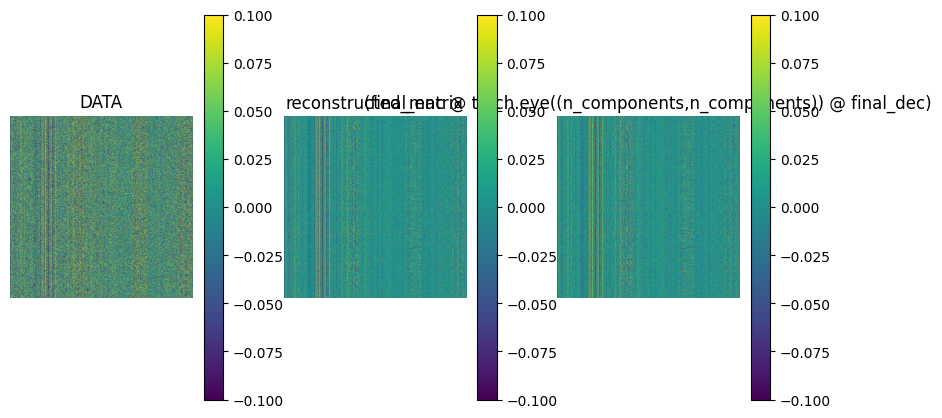

In [33]:

f, axs = plt.subplots(1, 3, figsize=(10, 5))

plt.sca(ax=axs[0])
# Display the image
plt.imshow(W_matrix_np, cmap='viridis', vmin=-0.1, vmax=0.1)  # Use cmap='gray' for single-channel images
plt.title('DATA')
cb = plt.colorbar()
plt.axis('off')  # Optional: remove axes
# plt.show()


plt.sca(ax=axs[1])
# Display the image
plt.imshow(reconstructed_matrix, cmap='viridis', vmin=cb.vmin, vmax=cb.vmax)  # Use cmap='gray' for single-channel images
plt.title('reconstructed_matrix')
plt.colorbar()
plt.axis('off')  # Optional: remove axes
# plt.show()

plt.sca(ax=axs[2])

# Display the image
plt.imshow((final_enc @ torch.eye(n_components) @ final_dec), cmap='viridis', vmin=cb.vmin, vmax=cb.vmax)  # Use cmap='gray' for single-channel images
plt.title('(final_enc @ torch.eye((n_components,n_components)) @ final_dec)') 
plt.colorbar()
plt.axis('off')  # Optional: remove axes
# plt.show()